In [1]:
import sys
sys.path.insert(0, '/Users/mayarubenstein/Desktop/Bocarsly')
import numpy
from matplotlib import pyplot as plt
import pandas

In [2]:
class CV:
    def __init__(self, electrode, analyte, date, scanRate):
        self.analyte = analyte
        self.data = date
        self.electrode = electrode
        self.initE = None
        self.highE = None
        self.lowE = None
        self.scanRate = scanRate #note that scan rate is in mv/sec
        self.Ep1 = None
        self.Ep2 = None
        self.Ah1 = None
        self.Ah2 = None
        self.ip1 = None
        self.ip2 = None
        self.potentials = None
        self.currents = None
        self.halfLength = None
        self.upperPotential = None
        self.lowerPotential = None
        self.upperCurrent = None
        self.lowerCurrent = None
    
    def represent(self):
        return self.electrode + " electrode in " + self.analyte + " at " + self.scanRate + " mV/s"
    
    def setInitE(self, initE):
        self.initE = initE
    
    def setHighE(self, highE):
        self.highE = highE
    
    def setLowE(self, lowE):
        self.lowE = lowE
    
    def setEp1(self, Ep1):
        self.Ep1 = Ep1
        
    def setIp1(self, ip1):
        self.ip1 = ip1
        
    def setAh1(self, Ah1):
        self.Ah1 = Ah1
        
    def setEp2(self, Ep2):
        self.Ep2 = Ep2
        
    def setIp2(self, ip2):
        self.ip2 = ip2
        
    def setAh2(self, Ah2):
        self.Ah2 = Ah2
    
    def inputCVPoints(self, potential, current):
        import numpy
        self.potentials = potential
        self.currents = current
        self.halfLength = int(len(current)/2)
        self.lowerPotential = potential[:self.halfLength]
        self.upperPotential = potential[self.halfLength:]
        self.lowerCurrent = current[:self.halfLength]
        self.upperCurrent = current[self.halfLength:]
        self.Ep1 = self.lowerPotential[numpy.argmin(self.lowerCurrent)]
        self.Ep2 = self.upperPotential[numpy.argmax(self.upperCurrent)]
        
    def Ehalf(self):
        if self.Ep1 == None or self.Ep2 == None:
            raise Exception("inadequate data")
        return (self.Ep1 + self.Ep2)/2
        
    def graph(self, graph):
        import matplotlib.pyplot as plt
        if self.potentials == None or self.currents == None:
            raise Exception("no scan data")  
        graph.plot(self.potentials, self.currents)
        graph.set_xlabel('potential (V)')
        graph.set_ylabel('current (Amp)')
    
    def normalize(self, array):
        range = max(array) - min(array)
        return [item/range for item in array]

    def differentiate(self, xarray, yarray):
        if len(xarray) != len(yarray):
            raise Exception("x and y arrays must be the same length")
        derivativesArray = []
        for i in range(len(xarray)-1):
            derivativesArray.append((yarray[i+1] - yarray[i])/(xarray[i+1] - xarray[i]))
        return derivativesArray
    
    def smootherSG(self, y, window_size, order, deriv = 0, rate = 1):
        import numpy
        from math import factorial
        y = numpy.array(y)
        try:
             window_size = numpy.abs(int(window_size))
             order = numpy.abs(int(order))
        except ValueError as msg:
             raise ValueError("window_size and order have to be of type int")
        if (window_size % 2 != 1 or window_size < 1):
            raise TypeError("window_size size must be a positive odd number")
        if window_size < order + 2:
            raise TypeError("window_size is too small for the polynomials order")
        order_range = range(order+1)
        half_window = (window_size -1) // 2
        b = numpy.mat([[k**i for i in order_range] for k in range(-half_window, half_window+1)])
        m = numpy.linalg.pinv(b).A[deriv] * rate**deriv * factorial(deriv)
        firstvals = y[0] - numpy.abs( y[1:half_window+1][::-1] - y[0] )
        lastvals = y[-1] + numpy.abs(y[-half_window-1:-1][::-1] - y[-1])
        y = numpy.concatenate((firstvals, y, lastvals))
        return numpy.convolve( m[::-1], y, mode='valid')
    
    def findZero(self, array):
        outputArray = []
        for i in range(len(array) -1):
            if (array[i+1]>0 and array[i]<0) or (array[i+1]<0 and array[i]>0):
                outputArray.append(i)
        return outputArray
    
    def upperSegmentInflectionIndex(self):
        import numpy
        xnorm = self.normalize(self.upperPotential)
        ynorm = self.normalize(self.upperCurrent)
        firstDeriv = self.differentiate(xnorm, ynorm)
        smoothFirstDeriv = self.smootherSG(firstDeriv, 101, 3)
        truncateSmoothFirstDerive= smoothFirstDeriv[100:] 
        #zeros = self.findZero(truncateSmoothFirstDerive)
        extreme = numpy.argmax(ynorm)
        truncateSmoothFirstDeriveTwo = truncateSmoothFirstDerive[:extreme]
        firstDerivMinusOne = [item -1 for item in truncateSmoothFirstDeriveTwo]
        return self.findZero(firstDerivMinusOne)[0] +100
    
    def upperSegmentInflectionPoint(self):
        i = self.upperSegmentInflectionIndex()
        return self.upperPotential[i], self.upperCurrent[i]

    def lowerSegmentInflectionIndex(self):
        import numpy
        xnorm = self.normalize(self.lowerPotential)
        ynorm = self.normalize(self.lowerCurrent)
        firstDeriv = self.differentiate(xnorm, ynorm)
        smoothFirstDeriv = self.smootherSG(firstDeriv, 101, 3)
        truncateSmoothFirstDerive= smoothFirstDeriv[100:] 
        #zeros = self.findZero(truncateSmoothFirstDerive)
        extreme = numpy.argmin(ynorm)
        truncateSmoothFirstDeriveTwo = truncateSmoothFirstDerive[:extreme]
        firstDerivMinusOne = [item -1 for item in truncateSmoothFirstDeriveTwo]
        return self.findZero(firstDerivMinusOne)[0] +100
    
    def lowerSegmentInflectionPoint(self):
        i = self.lowerSegmentInflectionIndex()
        return self.lowerPotential[i], self.lowerCurrent[i]
    
    def lowerCorrectionLine(self, x):
        x2, y2 = self.lowerSegmentInflectionPoint()
        x1 = self.lowerPotential[-1]
        y1 = self.lowerCurrent[-1]
        m = (y2 - y1)/(x2 - x1)
        return m*(x - x1) + y1
    
    def upperCorrectionLine(self, x):
        x1 = self.upperPotential[-1]
        y1 = self.upperCurrent[-1]
        x2, y2 = self.upperSegmentInflectionPoint()
        m = (y2 - y1)/(x2 - x1)
        return m*(x - x1) + y1
    
    def correctedLowerCurrent(self):
        import numpy
        return numpy.array(self.lowerCurrent) - self.lowerCorrectionLine(numpy.array(self.lowerPotential))
    
    def correctedEp1(self):
        import numpy
        i = self.lowerSegmentInflectionIndex()
        array = self.correctedLowerCurrent()[i:]
        j = numpy.argmin(array) + i
        return self.lowerPotential[j]
    
    def correctedMinCurrent(self):
        return min(self.correctedLowerCurrent()[self.lowerSegmentInflectionIndex():])
    
    def correctedUpperCurrent(self):
        import numpy
        return numpy.array(self.upperCurrent) - self.upperCorrectionLine(numpy.array(self.upperPotential))
    
    def correctedEp2(self):
        import numpy
        i = self.upperSegmentInflectionIndex()
        array = self.correctedUpperCurrent()[i:]
        j = numpy.argmax(array) + i
        return self.upperPotential[j]
        
    def correctedMaxCurrent(self):
        return max(self.correctedUpperCurrent()[self.upperSegmentInflectionIndex():])
        
    def graphInflectionPoints(self, graph, col):
        inflectLowerX, inflectLowerY = self.lowerSegmentInflectionPoint()
        inflectUpperX, inflectUpperY = self.upperSegmentInflectionPoint()
        graph.plot(inflectUpperX, inflectUpperY, '.', ms = 10, color = col)
        graph.plot(inflectLowerX, inflectLowerY, '.', ms = 10, color = col)
    
    def graphLowerLine(self, graph):
        import numpy
        graph.plot(self.lowerPotential, self.lowerCorrectionLine(numpy.array(self.lowerPotential)), 'k-')
    
    def graphUpperLine(self, graph):
        import numpy
        graph.plot(self.upperPotential, self.upperCorrectionLine(numpy.array(self.upperPotential)), 'k-')

In [3]:
datestrings = ['23052023']
electrodes = ['GCe4', 'CrGaOxe4']
analyte = 'Ferricyanide'
speeds = ['25', '50', '100', '150', '200', '250', '300', '500', '750', '1000', '2000']


def importCV(foldername, datestrings, electrodes, speeds, analyte, dataArray):
    for date in datestrings:
        for m in range(len(electrodes)):
            electrode = electrodes[m]
            for n in range(len(speeds)):
                speed = speeds[n]
                str = date + '-' + analyte + speed +"mvs" + '-' +electrode + '.txt'
                newObject = CV(electrode, analyte, date, speed)
                potentials = []
                currents = []
                try:
                    fileObject = open(foldername+'/'+str, 'r')
                    lines = fileObject.readlines()
                    i = 0
                    while (i < len(lines)):
                        line = lines[i]
                        if line[0:6] == 'Init E':
                            initE = line.split(" = ")[1]
                            initE = float(initE.strip())
                            newObject.setInitE(initE)
                        if line[0:4] == 'High':
                            highE = line.split(' = ')[1]
                            highE = float(highE.strip())
                            newObject.setHighE(highE)
                        if line[0:5] == 'Low E':
                            lowE = line.split(' = ')[1]
                            lowE = float(lowE.strip())
                            newObject.setLowE(lowE)
                        if line[0:9] == 'Segment 1':
                            i += 1
                            line1 = lines[i]
                            if line1[0:2] == 'Ep':
                                Ep1 = line1.split(" = ")[1]
                                Ep1 = Ep1.split('V')[0]
                                Ep1 = float(Ep1.strip())
                                newObject.setEp1(Ep1)
                                i += 1
                                line2 = lines[i]
                                ip1 = line2.split(" = ")[1]
                                ip1 = ip1.split('A')[0]
                                ip1 = float(ip1.strip())
                                newObject.setIp1(ip1)
                                i += 1
                                line3 = lines[i]
                                Ah1 = line3.split(" = ")[1]
                                Ah1 = Ah1.split('C')[0]
                                Ah1 = float(Ah1.strip())
                                newObject.setAh1(Ah1)
                        if line[0:9] == 'Segment 2':
                            i += 1
                            line1 = lines[i]
                            if line1[0:2] == "Ep":
                                Ep2 = line1.split(" = ")[1]
                                Ep2 = Ep2.split('V')[0]
                                Ep2 = float(Ep2.strip())
                                newObject.setEp2(Ep2)
                                i += 1
                                line2 = lines[i]
                                ip2 = line2.split(" = ")[1]
                                ip2 = ip2.split('A')[0]
                                ip2 = float(ip2.strip())
                                newObject.setIp2(ip2)
                                i += 1
                                line3 = lines[i]
                                Ah2 = line3.split(" = ")[1]
                                Ah2 = Ah2.split('C')[0]
                                Ah2 = float(Ah2.strip())
                                newObject.setAh2(Ah2)
                        if line[0:9] == 'Potential':
                            i += 2
                            while (i < len(lines)):
                                point = lines[i]
                                points = point.split(', ')
                                potentials.append(float(points[0]))
                                currents.append(float(points[1]))
                                i +=1
                        i += 1      
                    newObject.inputCVPoints(potentials, currents)
                    dataArray[n, m] = newObject
                except:
                    print("no " + str)


In [4]:
dataArray = numpy.ndarray((len(speeds), 2), dtype = CV)
print(dataArray.shape)
importCV('23052024-FeCN/GCE4', datestrings, electrodes, speeds, analyte, dataArray)
importCV('23052024-FeCn/CrGaOxe4', datestrings, electrodes, speeds, analyte, dataArray)

(11, 2)
no 23052023-Ferricyanide25mvs-CrGaOxe4.txt
no 23052023-Ferricyanide50mvs-CrGaOxe4.txt
no 23052023-Ferricyanide100mvs-CrGaOxe4.txt
no 23052023-Ferricyanide150mvs-CrGaOxe4.txt
no 23052023-Ferricyanide200mvs-CrGaOxe4.txt
no 23052023-Ferricyanide250mvs-CrGaOxe4.txt
no 23052023-Ferricyanide300mvs-CrGaOxe4.txt
no 23052023-Ferricyanide500mvs-CrGaOxe4.txt
no 23052023-Ferricyanide750mvs-CrGaOxe4.txt
no 23052023-Ferricyanide1000mvs-CrGaOxe4.txt
no 23052023-Ferricyanide2000mvs-CrGaOxe4.txt
no 23052023-Ferricyanide25mvs-GCe4.txt
no 23052023-Ferricyanide50mvs-GCe4.txt
no 23052023-Ferricyanide100mvs-GCe4.txt
no 23052023-Ferricyanide150mvs-GCe4.txt
no 23052023-Ferricyanide200mvs-GCe4.txt
no 23052023-Ferricyanide250mvs-GCe4.txt
no 23052023-Ferricyanide300mvs-GCe4.txt
no 23052023-Ferricyanide500mvs-GCe4.txt
no 23052023-Ferricyanide750mvs-GCe4.txt
no 23052023-Ferricyanide1000mvs-GCe4.txt
no 23052023-Ferricyanide2000mvs-GCe4.txt


In [5]:
print(dataArray.shape)
for row in range(dataArray.shape[0]):
    for column in range(dataArray.shape[1]):
        print(dataArray[row, column].represent())

(11, 2)
GCe4 electrode in Ferricyanide at 25 mV/s
CrGaOxe4 electrode in Ferricyanide at 25 mV/s
GCe4 electrode in Ferricyanide at 50 mV/s
CrGaOxe4 electrode in Ferricyanide at 50 mV/s
GCe4 electrode in Ferricyanide at 100 mV/s
CrGaOxe4 electrode in Ferricyanide at 100 mV/s
GCe4 electrode in Ferricyanide at 150 mV/s
CrGaOxe4 electrode in Ferricyanide at 150 mV/s
GCe4 electrode in Ferricyanide at 200 mV/s
CrGaOxe4 electrode in Ferricyanide at 200 mV/s
GCe4 electrode in Ferricyanide at 250 mV/s
CrGaOxe4 electrode in Ferricyanide at 250 mV/s
GCe4 electrode in Ferricyanide at 300 mV/s
CrGaOxe4 electrode in Ferricyanide at 300 mV/s
GCe4 electrode in Ferricyanide at 500 mV/s
CrGaOxe4 electrode in Ferricyanide at 500 mV/s
GCe4 electrode in Ferricyanide at 750 mV/s
CrGaOxe4 electrode in Ferricyanide at 750 mV/s
GCe4 electrode in Ferricyanide at 1000 mV/s
CrGaOxe4 electrode in Ferricyanide at 1000 mV/s
GCe4 electrode in Ferricyanide at 2000 mV/s
CrGaOxe4 electrode in Ferricyanide at 2000 mV/s


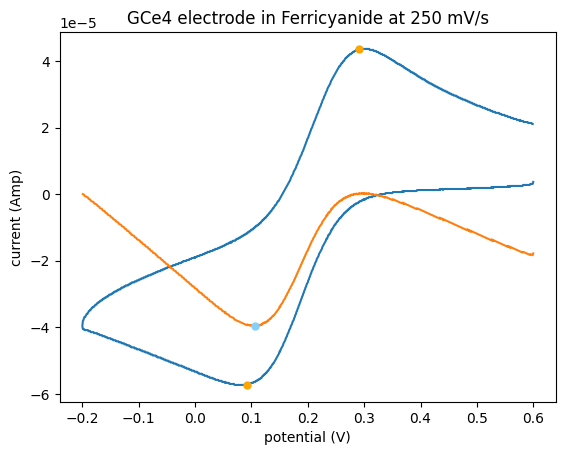

In [6]:

i = 5
j = 0
sample = dataArray[i,j]
fig, ax = plt.subplots()
sample.graph(ax)
ax.plot(sample.Ep1, min(sample.lowerCurrent), '.', color= 'orange', ms = 10)
ax.plot(sample.Ep2, max(sample.upperCurrent), '.', color= 'orange', ms = 10)
ax.plot(sample.lowerPotential, sample.correctedLowerCurrent())
ax.set_title(sample.represent())
ax.plot(sample.lowerPotential[numpy.argmin(sample.correctedLowerCurrent())], sample.correctedMinCurrent(), '.', color = 'lightskyblue', ms = 10)

In [7]:

byHandControl = pandas.read_csv('againGC.csv')
byHandControl = byHandControl.drop(columns = [byHandControl.columns[5], byHandControl.columns[6]])
#print(byHandControl)
byHandCrGaOx = pandas.read_csv('CrGaOxByHand.csv')
print(byHandCrGaOx)
byHand = [byHandControl, byHandCrGaOx]

   Scan rate    Ep1       Ip1    Ep2       Ip2  Unnamed: 5  Unnamed: 6
0         25  0.170 -0.000027  0.238  0.000027         NaN         NaN
1         50  0.167 -0.000038  0.242  0.000038         NaN         NaN
2        100  0.163 -0.000052  0.246  0.000051         NaN         NaN
3        150  0.158 -0.000061  0.249  0.000060         NaN         NaN
4        200  0.158 -0.000068  0.252  0.000068         NaN         NaN
5        250  0.153 -0.000076  0.254  0.000076         NaN         NaN
6        300  0.153 -0.000081  0.256  0.000080         NaN         NaN
7        500  0.146 -0.000097  0.262  0.000137         NaN         NaN
8        750  0.138 -0.000111  0.267  0.000112         NaN         NaN
9       1000  0.133 -0.000123  0.267  0.000116         NaN         NaN


In [8]:
#first lets test the glassy carbon baseline correction
column = 0
def quick(n):
    return str(round(n, 8))
for i in range(len(speeds)):
    currentCV = dataArray[i, column]
    print(currentCV.represent())
    print(byHandControl.loc[i, 'Scan rate'])
    print('Ep1 by program ' + quick(currentCV.correctedEp1()) + '||' + 'Ep1 by hand ' + quick(byHandControl.loc[i, 'Ep1']))
    print('ip1 by program ' + quick(currentCV.correctedMinCurrent()) + '||' + 'ip1 by hand ' + quick(byHandControl.loc[i, 'Ip1']))
    print('Ep2 by program ' + quick(currentCV.correctedEp2()) + '||' + 'Ep2 by hand ' + quick(byHandControl.loc[i, 'Ep2']))
    print('ip2 by program ' + quick(currentCV.correctedMaxCurrent()) + '||' + 'ip2 by hand ' + quick(byHandControl.loc[i, 'Ip2']))
    print('____________________________________________________________________________')

GCe4 electrode in Ferricyanide at 25 mV/s
25
Ep1 by program 0.142||Ep1 by hand 0.142
ip1 by program -1.821e-05||ip1 by hand -1.81e-05
Ep2 by program 0.254||Ep2 by hand 0.254
ip2 by program 1.907e-05||ip2 by hand 1.91e-05
____________________________________________________________________________
GCe4 electrode in Ferricyanide at 50 mV/s
50
Ep1 by program 0.138||Ep1 by hand 0.135
ip1 by program -2.403e-05||ip1 by hand -2.43e-05
Ep2 by program 0.259||Ep2 by hand 0.262
ip2 by program 2.507e-05||ip2 by hand 2.52e-05
____________________________________________________________________________
GCe4 electrode in Ferricyanide at 100 mV/s
100
Ep1 by program 0.126||Ep1 by hand 0.123
ip1 by program -3.194e-05||ip1 by hand -3.15e-05
Ep2 by program 0.268||Ep2 by hand 0.269
ip2 by program 3.358e-05||ip2 by hand 3.37e-05
____________________________________________________________________________
GCe4 electrode in Ferricyanide at 150 mV/s
150
Ep1 by program 0.116||Ep1 by hand 0.114
ip1 by program -3

In [9]:
def percentError(observed, accepted):
    return((observed-accepted)/accepted)*100

percentErrorGC = numpy.ndarray((len(speeds), 4), dtype = float)
column = 0
for i in range(len(speeds)):
    currentCV = dataArray[i, column]
    percentErrorGC[i, 0] = percentError(currentCV.correctedEp1(), byHandControl.loc[i, 'Ep1'])
    print(currentCV.correctedEp1(), byHandControl.loc[i, 'Ep1'])
    percentErrorGC[i, 1] = percentError(currentCV.correctedMinCurrent(), byHandControl.loc[i, 'Ip1'])
    percentErrorGC[i, 2] = percentError(currentCV.correctedEp2(), byHandControl.loc[i, 'Ep2'])
    print(currentCV.correctedEp2(), byHandControl.loc[i, 'Ep2'])
    percentErrorGC[i, 3] = percentError(currentCV.correctedMaxCurrent(), byHandControl.loc[i, 'Ip2'])
    
percentErrorCrGaOx = numpy.ndarray((len(speeds), 4), dtype = float)
column = 1
for i in range(10):
    currentCV = dataArray[i, column]
    percentErrorCrGaOx[i, 0] = percentError(currentCV.correctedEp1(), byHandCrGaOx.loc[i, 'Ep1'])
    print(currentCV.correctedEp1(), byHandCrGaOx.loc[i, 'Ep1'])
    percentErrorCrGaOx[i, 1] = percentError(currentCV.correctedMinCurrent(), byHandCrGaOx.loc[i, 'Ip1'])
    percentErrorCrGaOx[i, 2] = percentError(currentCV.correctedEp2(), byHandCrGaOx.loc[i, 'Ep2'])
    print(currentCV.correctedEp2(), byHandCrGaOx.loc[i, 'Ep2'])
    percentErrorCrGaOx[i, 3] = percentError(currentCV.correctedMaxCurrent(), byHandCrGaOx.loc[i, 'Ip2'])

print(percentErrorGC)
print(percentErrorCrGaOx)

0.142 0.142
0.254 0.254
0.138 0.135
0.259 0.262
0.126 0.123
0.268 0.269
0.116 0.114
0.278 0.278
0.115 0.115
0.278 0.278
0.107 0.103
0.286 0.286
0.101 0.097
0.29 0.29
0.087 0.087
0.3 0.3
0.075 0.075
0.311 0.311
0.069 0.069
0.318 0.321
0.044 0.044
0.334 0.336
0.17 0.17
0.238 0.238
0.167 0.167
0.242 0.242
0.163 0.163
0.246 0.246
0.158 0.158
0.249 0.249
0.158 0.158
0.252 0.252
0.153 0.153
0.254 0.254
0.153 0.153
0.256 0.256
0.146 0.146
0.262 0.262
0.138 0.138
0.263 0.267
0.133 0.133
0.267 0.267
[[ 0.          0.63074301  0.         -0.16947085]
 [ 2.22222222 -1.1143218  -1.14503817 -0.503644  ]
 [ 2.43902439  1.40015208 -0.37174721 -0.347786  ]
 [ 1.75438596 -0.3147154   0.         -0.73281238]
 [ 0.         -0.8656813   0.         -0.44285335]
 [ 3.88349515 -1.26917176  0.          0.87015113]
 [ 4.12371134 -1.33179601  0.         -0.38957272]
 [ 0.         -0.52970732  0.          0.52440119]
 [ 0.         -1.64990623  0.         -0.73252207]
 [ 0.         -1.75606448 -0.93457944 -0.4334

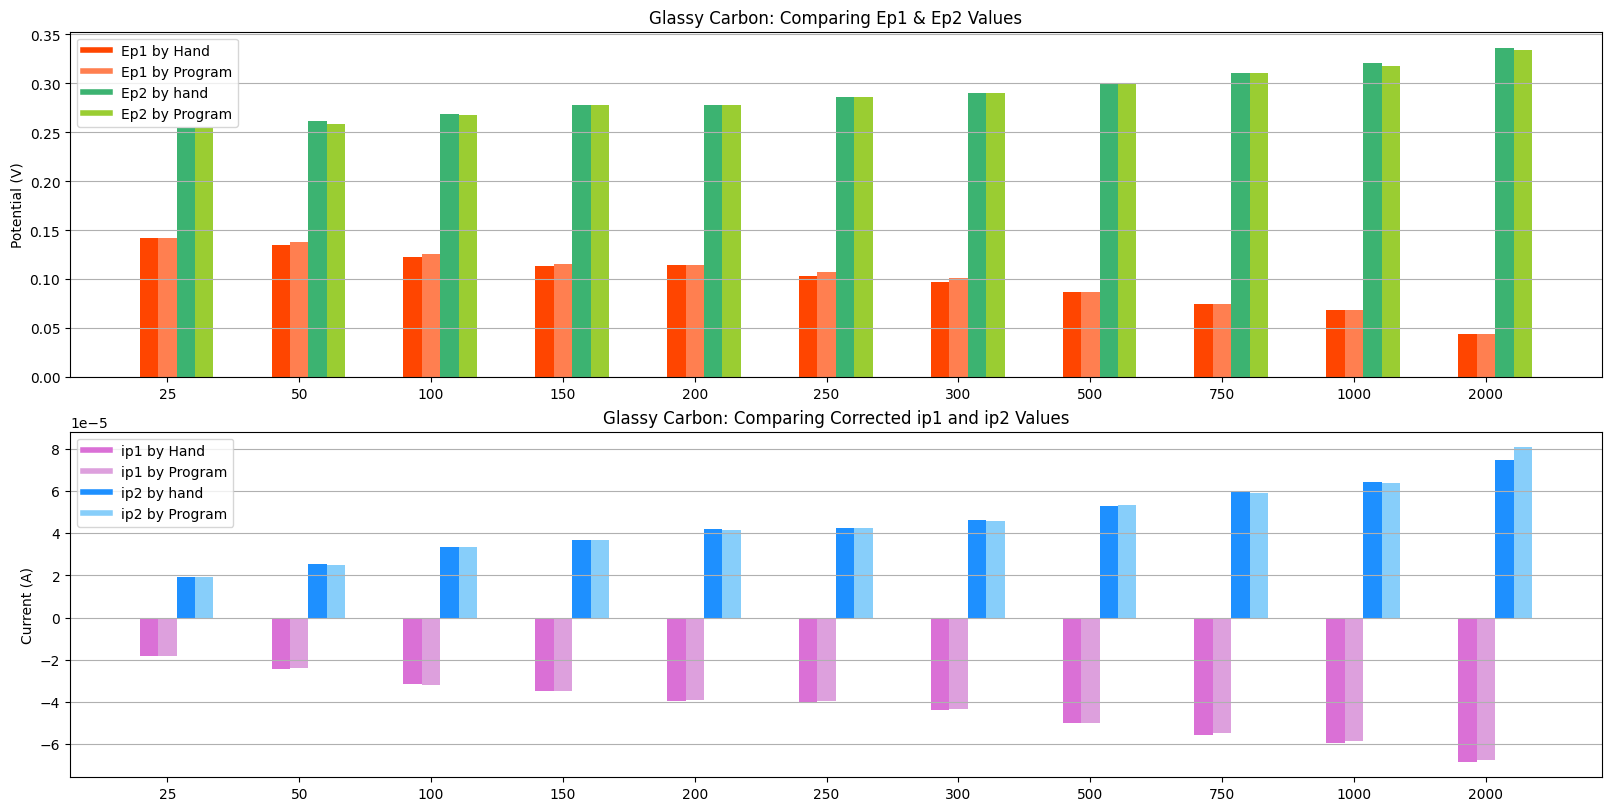

In [16]:
#Going to represent with a barplot
#just doing the control analysis
x = numpy.arange(11) #the label locations
width = 0.14 #the wdith of the bars
j =0

fig, ax = plt.subplots(2, 1, layout = 'constrained')
fig.set_figwidth(16)
fig.set_figheight(8)

ax[0].grid(axis = 'y')
ax[1].grid(axis = 'y')

for i in range(len(speeds)):
    currentCV = dataArray[i, j]
    measurements = ((byHandControl.loc[i, 'Ep1']),  (currentCV.correctedEp1()), (byHandControl.loc[i, 'Ep2']), (currentCV.correctedEp2()))
    currentMeasurements = (byHandControl.loc[i, 'Ip1'], currentCV.correctedMinCurrent(), byHandControl.loc[i, 'Ip2'], currentCV.correctedMaxCurrent())
    locs = [x[i] +r * width for r in range(4)]
    rects = ax[0].bar(locs, measurements, width, color = ['orangered', 'coral','mediumseagreen', 'yellowgreen'])
    rects = ax[1].bar(locs, currentMeasurements, width, label = speeds[i], color = ['orchid', 'plum', 'dodgerblue', 'lightskyblue'])
    
from matplotlib.lines import Line2D

custom_lines = [Line2D([0], [0], color='orangered', lw=4),
                Line2D([0], [0], color='coral', lw=4),
                Line2D([0], [0], color='mediumseagreen', lw=4),
                Line2D([0], [0], color='yellowgreen', lw=4)]
custom_lines_current = [Line2D([0], [0], color='orchid', lw=4),
                Line2D([0], [0], color='plum', lw=4),
                Line2D([0], [0], color='dodgerblue', lw=4),
                Line2D([0], [0], color='lightskyblue', lw=4)]
    
ax[0].set_ylabel('Potential (V)')
ax[1].set_ylabel('Current (A)')
ax[0].set_title('Glassy Carbon: Comparing Ep1 & Ep2 Values')
ax[1].set_title('Glassy Carbon: Comparing Corrected ip1 and ip2 Values')
ax[0].set_xticks(x + width, speeds)
ax[1].set_xticks(x + width, speeds)
ax[0].legend(custom_lines, ['Ep1 by Hand', 'Ep1 by Program', 'Ep2 by hand', 'Ep2 by Program'])
ax[1].legend(custom_lines_current, ['ip1 by Hand', 'ip1 by Program', 'ip2 by hand', 'ip2 by Program'])




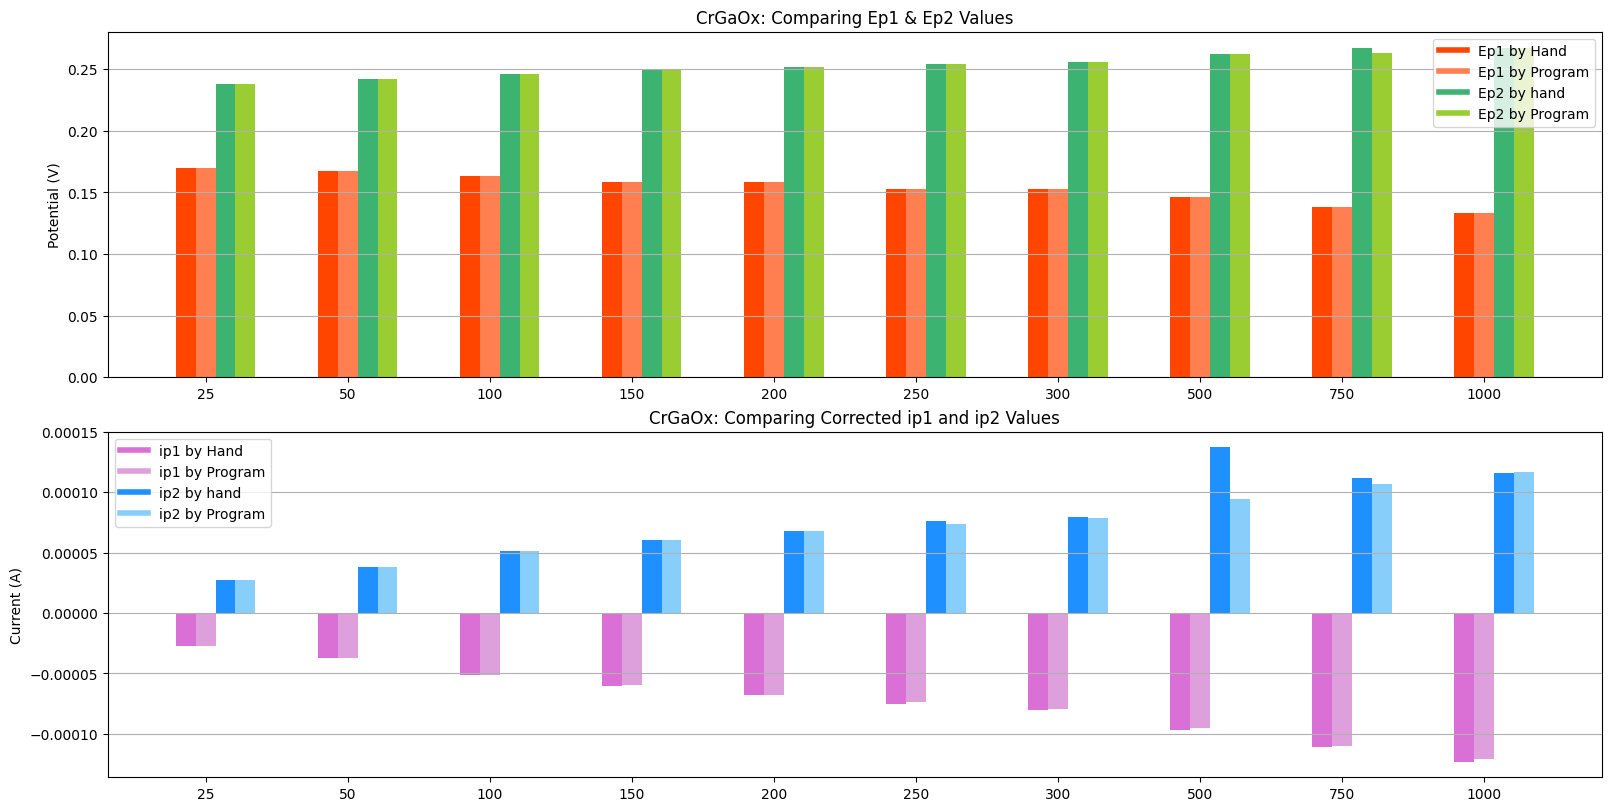

In [17]:
#now for the experimental electrode
x = numpy.arange(10) #the label locations
width = 0.14 #the wdith of the bars

fig, ax = plt.subplots(2, 1, layout = 'constrained')
fig.set_figwidth(16)
fig.set_figheight(8)

ax[0].grid(axis = 'y')
ax[1].grid(axis = 'y')
j = 1

for i in range(10):
    currentCV = dataArray[i, j]
    measurements = ((byHandCrGaOx.loc[i, 'Ep1']),  (currentCV.correctedEp1()), (byHandCrGaOx.loc[i, 'Ep2']), (currentCV.correctedEp2()))
    currentMeasurements = (byHandCrGaOx.loc[i, 'Ip1'], currentCV.correctedMinCurrent(), byHandCrGaOx.loc[i, 'Ip2'], currentCV.correctedMaxCurrent())
    locs = [x[i] +r * width for r in range(4)]
    rects = ax[0].bar(locs, measurements, width, color = ['orangered', 'coral','mediumseagreen', 'yellowgreen'])
    rects = ax[1].bar(locs, currentMeasurements, width, label = speeds[i], color = ['orchid', 'plum', 'dodgerblue', 'lightskyblue'])
    
from matplotlib.lines import Line2D

custom_lines = [Line2D([0], [0], color='orangered', lw=4),
                Line2D([0], [0], color='coral', lw=4),
                Line2D([0], [0], color='mediumseagreen', lw=4),
                Line2D([0], [0], color='yellowgreen', lw=4)]
custom_lines_current = [Line2D([0], [0], color='orchid', lw=4),
                Line2D([0], [0], color='plum', lw=4),
                Line2D([0], [0], color='dodgerblue', lw=4),
                Line2D([0], [0], color='lightskyblue', lw=4)]
    
ax[0].set_ylabel('Potential (V)')
ax[1].set_ylabel('Current (A)')
ax[0].set_title('CrGaOx: Comparing Ep1 & Ep2 Values')
ax[1].set_title('CrGaOx: Comparing Corrected ip1 and ip2 Values')
ax[0].set_xticks(x + width, speeds[:10])
ax[1].set_xticks(x + width, speeds[:10])
ax[0].legend(custom_lines, ['Ep1 by Hand', 'Ep1 by Program', 'Ep2 by hand', 'Ep2 by Program'])
ax[1].legend(custom_lines_current, ['ip1 by Hand', 'ip1 by Program', 'ip2 by hand', 'ip2 by Program'])

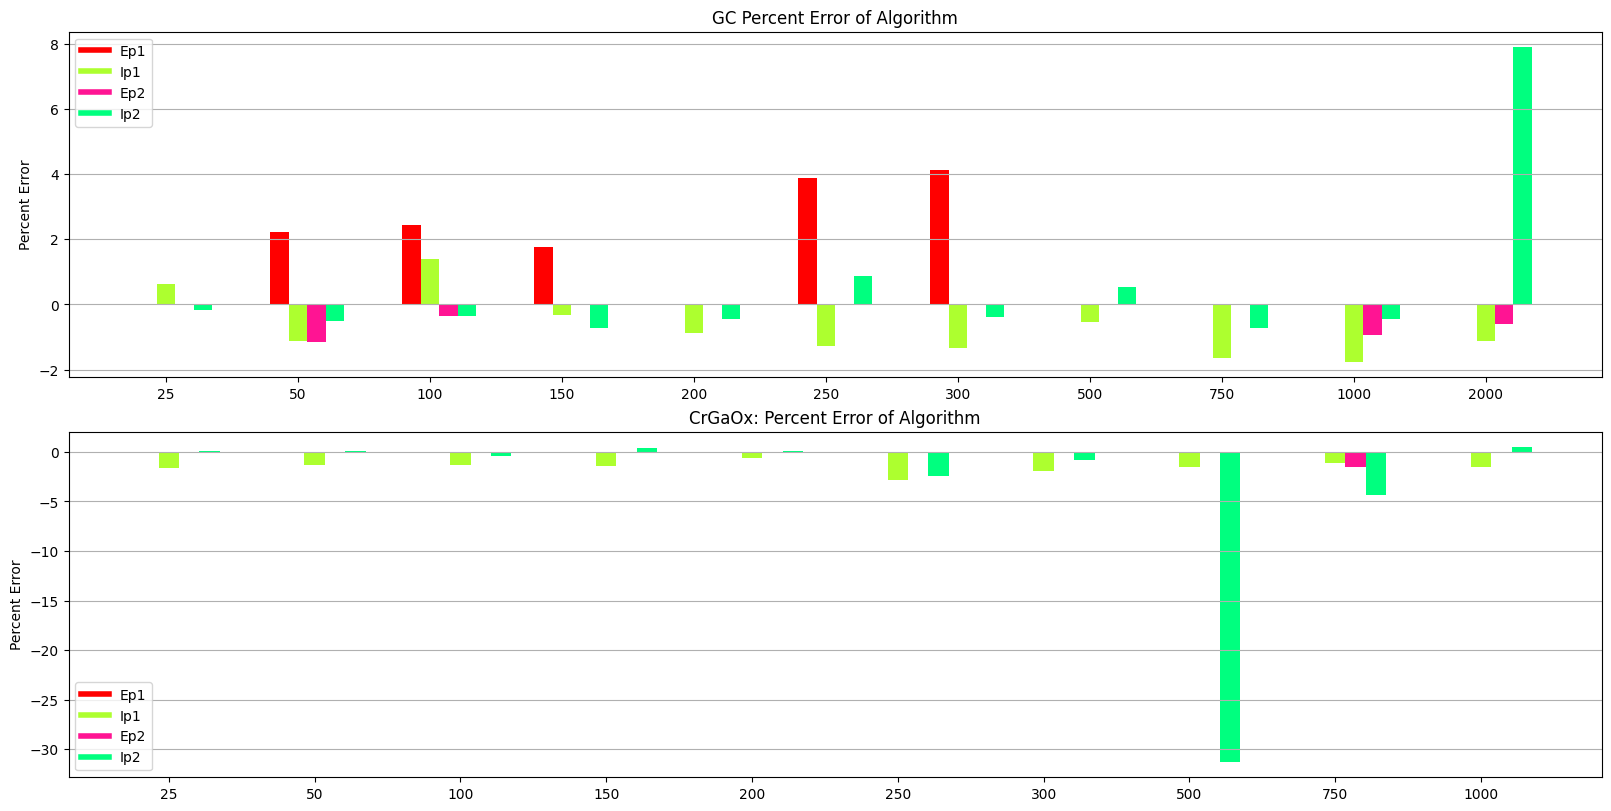

In [19]:
xGC = numpy.arange(11)
xCrGaOx = numpy.arange(10)
width = 0.14

fig, ax = plt.subplots(2, 1, layout = 'constrained')
fig.set_figwidth(16)
fig.set_figheight(8)

ax[0].grid(axis = 'y')
ax[1].grid(axis = 'y')
j = 1


for i in range(11):
    locsGC = [xGC[i] +r * width for r in range(4)]
    rects = ax[0].bar(locsGC, percentErrorGC[i,:], width, color = ['red', 'greenyellow','deeppink', 'springgreen'])
    try:
        locsCrGaOx= [xCrGaOx[i] +r * width for r in range(4)]
        rects = ax[1].bar(locsCrGaOx, percentErrorCrGaOx[i,:], width, label = speeds[i], color = ['red', 'greenyellow','deeppink', 'springgreen'])
    except:
        continue
    
from matplotlib.lines import Line2D

custom_lines = [Line2D([0], [0], color='red', lw=4),
                Line2D([0], [0], color='greenyellow', lw=4),
                Line2D([0], [0], color='deeppink', lw=4),
                Line2D([0], [0], color='springgreen', lw=4)]
    
ax[0].set_ylabel('Percent Error')
ax[1].set_ylabel('Percent Error')
ax[0].set_title('GC Percent Error of Algorithm')
ax[1].set_title('CrGaOx: Percent Error of Algorithm')
ax[0].set_xticks(xGC + width, speeds)
ax[1].set_xticks(xCrGaOx + width, speeds[:10])
ax[0].legend(custom_lines, ['Ep1', 'Ip1', 'Ep2', 'Ip2'])
ax[1].legend(custom_lines, ['Ep1', 'Ip1', 'Ep2', 'Ip2'])

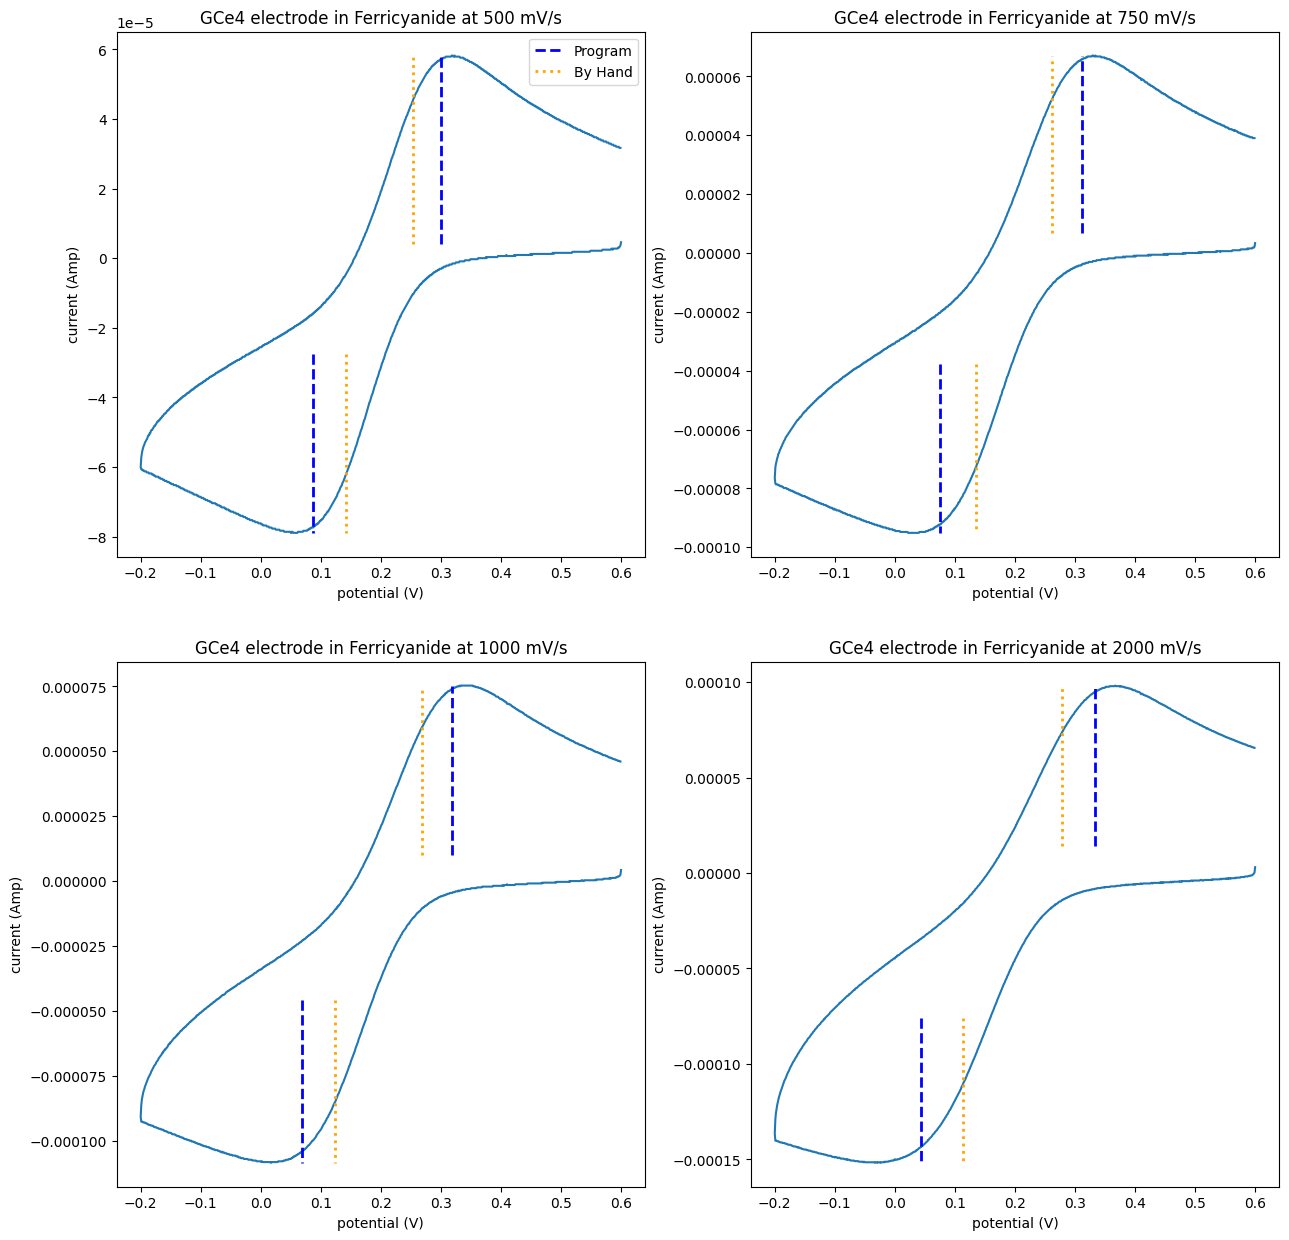

In [13]:
tuples = [(7,0), (8, 0), (9,0), (10, 0)]

def findGraph(n):
    return int(n/2), n%2

fig, ax = plt.subplots(2,2)
fig.set_figwidth(15)
fig.set_figheight(15)
for i in range(len(tuples)):
    currentGraph = dataArray[tuples[i][0], tuples[i][1]]
    currentPlot = ax[findGraph(i)[0], findGraph(i)[1]]
    currentGraph.graph(currentPlot)
    upperLineX = currentGraph.correctedEp2()
    upperLineYMin = currentGraph.upperCorrectionLine(upperLineX)
    lowerLineX=currentGraph.correctedEp1()
    lowerLineYMax =  currentGraph.lowerCorrectionLine(lowerLineX)
    currentPlot.vlines(upperLineX, upperLineYMin, max(currentGraph.upperCurrent), colors = 'blue', ls = '--', lw =2)
    currentPlot.vlines(lowerLineX, lowerLineYMax, min(currentGraph.lowerCurrent), colors = 'blue', ls = '--', lw = 2)
    currentPlot.vlines(byHand[0].loc[i, 'Ep2'], upperLineYMin, max(currentGraph.upperCurrent), colors = 'orange', ls = 'dotted', lw = 2)
    currentPlot.vlines(byHand[0].loc[i, 'Ep1'], lowerLineYMax, min(currentGraph.lowerCurrent), colors = 'orange', ls = 'dotted', lw  = 2)
    currentPlot.set_title(currentGraph.represent())

custom_lines = [Line2D([0], [0], color='blue', lw=2, ls = '--'),
                Line2D([0], [0], color='orange', lw=2, ls = 'dotted')]

ax[0, 0].legend(custom_lines, ['Program', 'By Hand'])

Program Value for Ip2
9.419675659229209e-05
By Hand Value for Ip2
0.000137
Max Current
0.000118
Intercept on the Correction Line
2.423032657200812e-05


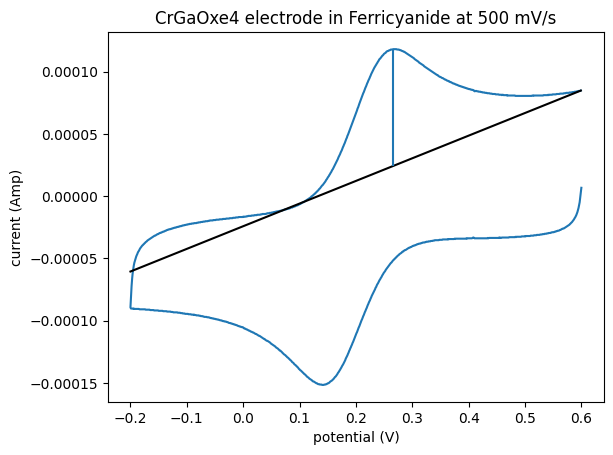

In [14]:
currentCV = dataArray[7,1]
fig, ax = plt.subplots()
currentCV.graph(ax)
ax.set_title(currentCV.represent())
currentCV.graphUpperLine(ax)
print('Program Value for Ip2')
print(currentCV.correctedMaxCurrent())
print('By Hand Value for Ip2')
print(byHand[1].loc[7, 'Ip2'])
print('Max Current')
print(max(currentCV.upperCurrent))
print('Intercept on the Correction Line')
print(currentCV.upperCorrectionLine(currentCV.upperPotential[numpy.argmax(currentCV.upperCurrent)]))
ax.vlines(currentCV.Ep2, 2.4e-5, 2.4e-5 + currentCV.correctedMaxCurrent())

In [15]:
import numpy
a = [1, 2, 3, 4]
b = [1, 1, 1, 1]
c = [a[x] - b[x] for x in range(len(a))]
d = numpy.array(a) - numpy.array(b)
print(c[2:])
print(d)

[2, 3]
[0 1 2 3]
